STEP 1: Loading libraries

In [2]:

# These libraries are categorized for clarity and learning purposes.

# ----------------------------------------------
# 1. DATA HANDLING & NUMERICAL COMPUTATION
# ----------------------------------------------
import numpy as np   # For numerical arrays, mathematical operations, and vector processing
import pandas as pd  # For structured data manipulation using DataFrames

# ----------------------------------------------
# 2. VISUALIZATION LIBRARIES
# ----------------------------------------------
import matplotlib.pyplot as plt  # Base Python plotting library for bar, line, scatter plots
import seaborn as sns            # High-level visualization library built on matplotlib

# ----------------------------------------------
# 3. SCIKIT-LEARN: ML & TEXT FEATURE ENGINEERING
# ----------------------------------------------
from sklearn.datasets import fetch_20newsgroups  # Loads the 20 newsgroups dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # Converts text to numeric features
from sklearn.preprocessing import OneHotEncoder  # Converts categorical tokens (e.g., words) to one-hot vectors
from sklearn.linear_model import LogisticRegression  # Classification algorithm
from sklearn.model_selection import train_test_split  # Splits dataset into training and test sets
from sklearn.metrics import classification_report, confusion_matrix  # Model evaluation metrics

# ----------------------------------------------
# 4. NATURAL LANGUAGE PROCESSING (NLTK)
# ----------------------------------------------
import nltk
from nltk.tokenize import word_tokenize  # Tokenizes sentences into words
from nltk.corpus import stopwords        # Common English stopwords (e.g., 'the', 'is')
from nltk import pos_tag                 # Part-of-speech tagging
import string                            # For handling punctuation symbols

# ----------------------------------------------
# 5. DOWNLOAD NLTK RESOURCES (ENSURE AVAILABILITY)
# ----------------------------------------------
# We are now using try-except blocks and nltk.data.find() to:
# Prevent LookupError at runtime (e.g., "punkt not found")
# Avoid unnecessary re-downloads if resources already exist


try:
    nltk.data.find('tokenizers/punkt')  # Checks if 'punkt' tokenizer is already available
except LookupError:
    nltk.download('punkt', quiet=True, raise_on_error=True)  # Downloads 'punkt' only if missing

try:
    nltk.data.find('corpora/stopwords')  # Checks if English stopwords list is available
except LookupError:
    nltk.download('stopwords', quiet=True, raise_on_error=True)  # Downloads it only if not found

try:
    nltk.data.find('taggers/averaged_perceptron_tagger')  # Checks if POS tagger model is available
except LookupError:
    nltk.download('averaged_perceptron_tagger', quiet=True, raise_on_error=True)  # Downloads only if needed

# ----------------------------------------------
# WHY:
# - Sets up the environment and tools needed for NLP and ML
# - Ensures resources are available before using them (fixes LookupError)
# - Makes the script more robust, especially on new setups or cloud platforms
# - Organizing imports helps beginners understand each library's role
# ==============================================


STEP 2: Load and Inspect the 20 Newsgroups Dataset

In [3]:
# ------------------------------------------------
# 1. Load the text dataset (remove extra noise)
# ------------------------------------------------
# We're using the 'all' subset (train + test combined), and removing metadata like headers/footers/quotes
# This helps us focus only on the core body content of emails/posts
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# ------------------------------------------------
# 2. Wrap the data into a pandas DataFrame for ease of use
# ------------------------------------------------
import pandas as pd

df = pd.DataFrame({
    'text': newsgroups.data,     # Raw article text (emails, forum posts, etc.)
    'target': newsgroups.target  # Numeric category labels (0 to 19)
})

# ------------------------------------------------
# 3. Check the shape of the dataset
# ------------------------------------------------
print("Dataset shape:", df.shape)  # Output: (18846, 2)

# ------------------------------------------------
# 4. View the target categories
# ------------------------------------------------
print("\nTarget categories (20 newsgroups):")
for i, cat in enumerate(newsgroups.target_names):
    print(f"{i}: {cat}")

# ------------------------------------------------
# 5. View a few sample rows of raw data
# ------------------------------------------------
print("\nSample rows:")
print(df[['text', 'target']].head(3))  # Shows first 3 documents

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - The dataset contains 18846 documents (text samples) with 20 target categories.
# - Each document is a long piece of unstructured text (newsgroup post).
# - The 'target' column is a numeric class label (0–19), where each number represents a category.
# - We'll later convert these into meaningful labels using `newsgroups.target_names`.
# - This step helps us understand the nature and volume of data before cleaning or modeling.
# ==============================================


Dataset shape: (18846, 2)

Target categories (20 newsgroups):
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc

Sample rows:
                                                text  target
0  \n\nI am sure some bashers of Pens fans are pr...      10
1  My brother is in the market for a high-perform...       3
2  \n\n\n\n\tFinally you said what you dream abou...      17


Downloading NLTK right before Text cleaning to avoid lookup error

In [4]:
# ----------------------------------------------
#  DOWNLOAD NLTK RESOURCES (ENSURE AVAILABILITY)
# ----------------------------------------------
# We are now using try-except blocks and nltk.data.find() to:
# Prevent LookupError at runtime (e.g., "punkt not found")
# Avoid unnecessary re-downloads if resources already exist


try:
    nltk.data.find('tokenizers/punkt')  # Checks if 'punkt' tokenizer is already available
except LookupError:
    nltk.download('punkt', quiet=True, raise_on_error=True)  # Downloads 'punkt' only if missing

try:
    nltk.data.find('corpora/stopwords')  # Checks if English stopwords list is available
except LookupError:
    nltk.download('stopwords', quiet=True, raise_on_error=True)  # Downloads it only if not found

try:
    nltk.data.find('taggers/averaged_perceptron_tagger')  # Checks if POS tagger model is available
except LookupError:
    nltk.download('averaged_perceptron_tagger', quiet=True, raise_on_error=True)  # Downloads only if needed

# Add download for 'punkt_tab' which is needed by word_tokenize
try:
    nltk.data.find('tokenizers/punkt_tab')  # Checks if 'punkt_tab' is available
except LookupError:
    nltk.download('punkt_tab', quiet=True, raise_on_error=True)  # Downloads 'punkt_tab' only if missing

STEP 3: Basic Text Cleaning

In [5]:
# ------------------------------------------------
# 1. Define the text cleaning function
# ------------------------------------------------
# This function takes raw text and:
# - Splits it into tokens (words)
# - Converts everything to lowercase
# - Removes punctuation and stopwords
# - Returns the cleaned sentence as a single string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

def clean_text(text):
    tokens = word_tokenize(text)                            # Break sentence into individual words
    tokens = [t.lower() for t in tokens if t.isalpha()]     # Keep only alphabetic words, discard numbers/punctuation
    tokens = [t for t in tokens if t not in stopwords.words('english')]  # Remove stopwords like 'the', 'is', 'and'
    return " ".join(tokens)                                 # Join back into cleaned sentence

# ------------------------------------------------
# 2. Apply the cleaning on a small subset (for speed)
# ------------------------------------------------
# We'll use only 2000 samples from the full 18846 to reduce processing time during the lab
df_small = df.sample(2000, random_state=42).copy()          # Random 2000 documents
df_small['clean_text'] = df_small['text'].apply(clean_text) # Apply the cleaning

# ------------------------------------------------
# 3. View a sample cleaned text
# ------------------------------------------------
print("Original Text Sample:\n")
print(df_small['text'].iloc[0][:500])  # Show first 500 chars of original
print("\nCleaned Text:\n")
print(df_small['clean_text'].iloc[0])  # Show cleaned version

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - The raw text contains a mix of capital letters, punctuation, and non-relevant words.
# - The cleaned version is more focused and ready for feature extraction.
# - This preprocessing improves model accuracy and reduces noise.
# - Important: Without removing stopwords or punctuation, models would be biased by frequent but uninformative words.
# ==============================================


Original Text Sample:




	The runner can leave his base at any time.  If the ball is caught,
he's got to tag up.  If it isn't caught, he _doesn't_ have to tag up at
all.  So, if he's feeling lucky, your runner at second can sprint for glory
as soon as the ball is popped up.  If it isn't caught, he's probably scored
a run.  If it is, he's probably headed for AAA.  

	The only effect the infield fly has is to make the batter out,
thereby removing the force on the runners on base.  All other rules apply,
as if you were 

Cleaned Text:

runner leave base time ball caught got tag caught tag feeling lucky runner second sprint glory soon ball popped caught probably scored run probably headed aaa effect infield fly make batter thereby removing force runners base rules apply standing second first open ball popped


STEP 4: Text Classification (TF-IDF + Logistic Regression)

TF-IDF Matrix Shape: (2000, 3000)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.80      0.20      0.32        20
           1       0.29      0.53      0.37        19
           2       0.48      0.40      0.43        25
           3       0.50      0.23      0.31        22
           4       0.62      0.68      0.65        22
           5       0.89      0.68      0.77        25
           6       0.67      0.50      0.57        20
           7       0.55      0.60      0.57        20
           8       0.55      0.43      0.48        14
           9       0.82      0.64      0.72        22
          10       0.82      0.82      0.82        17
          11       0.55      0.50      0.52        24
          12       0.22      0.50      0.31        22
          13       0.49      0.82      0.61        22
          14       0.75      0.60      0.67        10
          15       0.46      0.55      0.50        22
          16

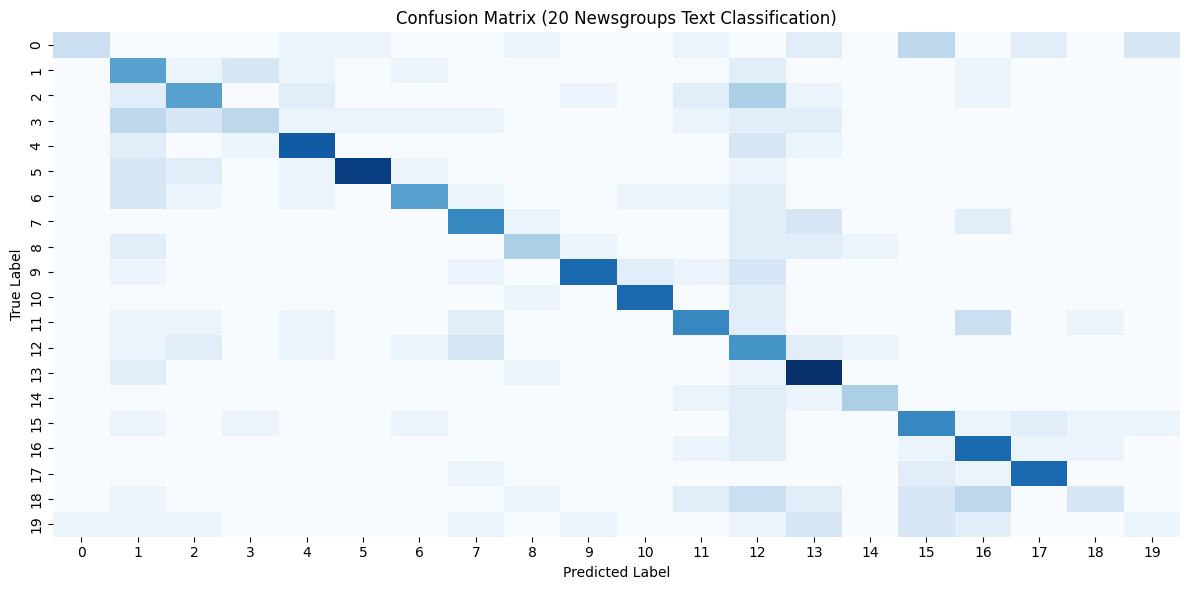

In [6]:
# Objective:
# - Convert text into numeric features using TF-IDF
# - Train a Logistic Regression classifier
# - Evaluate classification results using standard metrics
# - Visualize model performance using a confusion matrix

# ---------------------------------------------------------
# 1 Import Required Modules
# ---------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 2 TF-IDF Vectorization (Convert Cleaned Text to Features)
# ---------------------------------------------------------
# TF-IDF reduces weight of common words and boosts rare but meaningful ones
# We retain top 3000 words (features) for simplicity and performance
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df_small['clean_text'])  # Returns sparse matrix (documents x words)

print("TF-IDF Matrix Shape:", X_tfidf.shape)  # Example: (2000, 3000)

# ---------------------------------------------------------
# 3 Train-Test Split (80% Train, 20% Test)
# ---------------------------------------------------------
# df_small['target'] contains the numeric labels for each document
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df_small['target'], test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 4 Train the Logistic Regression Model
# ---------------------------------------------------------
# Logistic Regression is simple and effective for text classification
# max_iter=1000 ensures convergence on high-dimensional sparse data
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# ---------------------------------------------------------
# 5 Predict on Test Data and Evaluate
# ---------------------------------------------------------
y_pred = clf.predict(X_test)

# Classification report shows precision, recall, f1-score per class
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# 6 Confusion Matrix Visualization
# ---------------------------------------------------------
# Confusion matrix helps understand how predictions match true labels
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, cmap='Blues', annot=False, fmt='d', cbar=False)
plt.title("Confusion Matrix (20 Newsgroups Text Classification)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# - TF-IDF (Term Frequency–Inverse Document Frequency) transforms raw text into numeric features
#   giving weight to rare but informative terms.
# - Logistic Regression is used here to classify documents into 20 categories using those features.
# - The classification report gives class-wise metrics:
#     - Precision: Out of predicted positives, how many were correct.
#     - Recall: Out of actual positives, how many were correctly predicted.
#     - F1-Score: Balance between precision and recall.
# - Confusion matrix shows how many documents were correctly classified vs. misclassified.
# - This step completes a full text classification pipeline:
#     1. Preprocess text
#     2. Convert to TF-IDF vectors
#     3. Train Logistic Regression
#     4. Evaluate and visualize results

#
# This forms the backbone of many industrial NLP pipelines, and is a great first model before trying deep learning.


STEP 5: TF-IDF Vectorization

In [7]:
# ------------------------------------------------
# TF-IDF vectorizer transforms text into weighted numerical features.
# It reduces the influence of frequent words and boosts rare but important words.
# ------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer: keep top 3000 features (by frequency)
tfidf = TfidfVectorizer(max_features=3000)

# Apply TF-IDF to cleaned text to generate a sparse feature matrix
X_tfidf = tfidf.fit_transform(df_small['clean_text'])

# ------------------------------------------------
# Check shape of resulting TF-IDF matrix
# ------------------------------------------------
print("TF-IDF Matrix Shape:", X_tfidf.shape)
# Example output: (2000, 3000) = 2000 documents and 3000 top weighted features

# ------------------------------------------------
# Let's analyze most important features by average TF-IDF value
# ------------------------------------------------

feature_names = tfidf.get_feature_names_out()        # List of all feature terms
tfidf_means = X_tfidf.mean(axis=0).A1                # Compute mean TF-IDF score for each term across all docs
sorted_indices = np.argsort(tfidf_means)[::-1][:10]  # Get indices of top 10 highest TF-IDF features

# Print the top 10 most important features with their TF-IDF scores
print("Top 10 TF-IDF Features (by average importance across docs):")
for idx in sorted_indices:
    print(f"{feature_names[idx]}: {tfidf_means[idx]:.4f}")

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - These words contribute most to document uniqueness.
# - High TF-IDF = rare but significant across the corpus.
# - Unlike raw counts, TF-IDF avoids giving high score to frequent stopwords.
# ==============================================


TF-IDF Matrix Shape: (2000, 3000)
Top 10 TF-IDF Features (by average importance across docs):
would: 0.0260
one: 0.0219
get: 0.0187
like: 0.0178
know: 0.0168
people: 0.0152
think: 0.0150
could: 0.0141
use: 0.0137
also: 0.0136


STEP 6: Unigrams using CountVectorizer

In [8]:
# ------------------------------------------------
# Convert cleaned text into feature matrix
# Each row = document, Each column = word (unigram)
# Value = number of times word appears in document
# ------------------------------------------------
from sklearn.feature_extraction.text import CountVectorizer

cv_uni = CountVectorizer()                        # By default, creates unigram features
X_uni = cv_uni.fit_transform(df_small['clean_text'])  # Apply to cleaned text

# ------------------------------------------------
# Check dimensions of feature matrix
# ------------------------------------------------
print("Unigram Feature Matrix Shape:", X_uni.shape)
# Example output: (2000, 11566) => 2000 docs, 11566 unique unigrams

# ------------------------------------------------
# Display first 10 unigrams (features/columns)
# ------------------------------------------------
print("First 10 Unigram Features:")
print(cv_uni.get_feature_names_out()[:10])

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - Every document is now a row of numbers representing word frequencies.
# - Large number of columns because vocabulary size is high.
# - Helps convert unstructured text into structured numeric format.
# ==============================================


Unigram Feature Matrix Shape: (2000, 25307)
First 10 Unigram Features:
['aa' 'aaa' 'aaai' 'aacc' 'aaf' 'aap' 'aaplay' 'aaron' 'aaronson'
 'aaroundpluto']


STEP 7: N-Grams (Unigrams + Bigrams + Trigrams)


In [9]:
# ------------------------------------------------
# CountVectorizer with ngram_range=(1, 3) will extract:
# - unigrams: single words
# - bigrams: pairs of consecutive words
# - trigrams: triplets of consecutive words
# We also limit the output to top 30 most frequent n-grams
# ------------------------------------------------

from sklearn.feature_extraction.text import CountVectorizer

cv_ngram = CountVectorizer(ngram_range=(1, 3), max_features=30)  # Extract top 30 n-grams (1 to 3 words)
X_ngram = cv_ngram.fit_transform(df_small['clean_text'])         # Fit and transform on cleaned text

# ------------------------------------------------
# Check the shape of the resulting matrix
# ------------------------------------------------
print("N-Gram Feature Matrix Shape:", X_ngram.shape)  # Shape: (documents, n-gram features)

# ------------------------------------------------
# Display the top 30 n-gram features extracted
# ------------------------------------------------
print("Top 30 N-Gram Features (unigrams + bigrams + trigrams):")
print(cv_ngram.get_feature_names_out())

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - N-grams capture local context and word combinations.
# - Example: "new york city" as a trigram gives more insight than individual words.
# - Bigrams and trigrams help detect phrases like "machine learning", "data science", etc.
# - Caution: More n-grams = more features = more sparsity.
# ==============================================


N-Gram Feature Matrix Shape: (2000, 30)
Top 30 N-Gram Features (unigrams + bigrams + trigrams):
['also' 'could' 'even' 'file' 'first' 'get' 'good' 'know' 'like' 'make'
 'many' 'max' 'max max' 'max max max' 'may' 'much' 'new' 'one' 'people'
 'see' 'system' 'think' 'time' 'two' 'us' 'use' 'used' 'way' 'well'
 'would']


STEP 8: One-Hot Encoding (Manual Illustration)

In [10]:
# ------------------------------------------------
# One-hot encoding is used for converting categorical labels into binary vectors.
# Let's simulate a small vocabulary of words and encode them manually.
# ------------------------------------------------

from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Example list of three words
words = ['science', 'religion', 'hockey']

# Reshape for sklearn (expects 2D array)
word_array = np.array(words).reshape(-1, 1)

# Initialize one-hot encoder
enc = OneHotEncoder(sparse_output=False)

# Fit and transform the data
ohe_result = enc.fit_transform(word_array)

# Display the one-hot encoded vectors
print("One-Hot Encoded Output:")
for word, vec in zip(words, ohe_result):
    print(f"{word}: {vec}")

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - Each word becomes a vector with '1' at its own index, and 0 elsewhere.
# - Helps convert nominal categories into machine-readable form.
# - This is mainly for illustration. For text, use TF-IDF/CountVectorizer instead.
# ==============================================

One-Hot Encoded Output:
science: [0. 0. 1.]
religion: [0. 1. 0.]
hockey: [1. 0. 0.]


STEP 9: POS Tagging (Part-of-Speech) + Visualization

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Sample POS Tags (first 10):
[('well', 'RB'), ('ftp', 'JJ'), ('site', 'NN'), ('got', 'VBD'), ('number', 'NN'), ('signetics', 'NNS'), ('bbs', 'VBP'), ('signetics', 'NNS'), ('bbs', 'VBP'), ('contain', 'NN')]


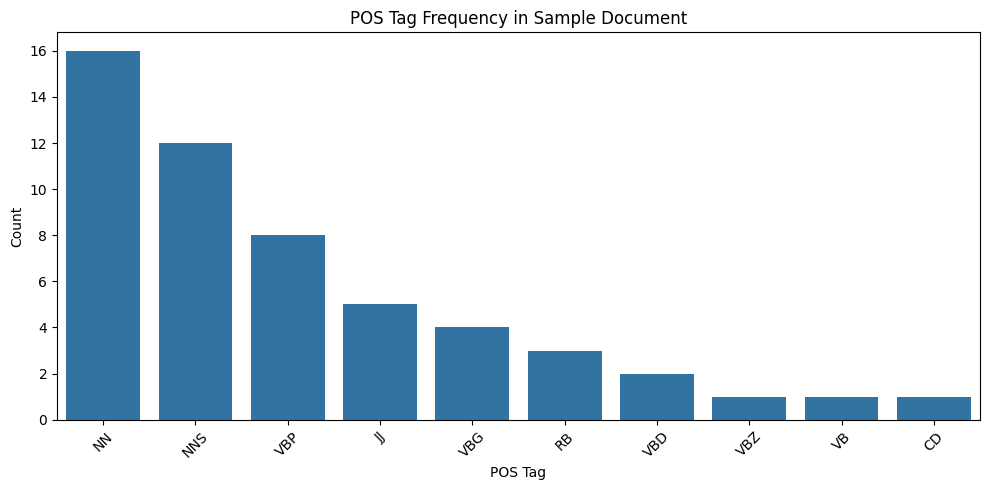

In [11]:
# ------------------------------------------------
# POS tagging helps in grammatical analysis: noun, verb, adj, etc.
# Useful when we want to extract only nouns or verbs as features.
# ------------------------------------------------

import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Ensure POS tagger model is available (required in NLTK 3.8+)
# ------------------------------------------------
nltk.download('averaged_perceptron_tagger_eng')  # Required for nltk.pos_tag() to work in latest NLTK

# ------------------------------------------------
# Select and tokenize one cleaned document
# ------------------------------------------------
sample_doc = df_small['clean_text'].iloc[1]       # Choose one document
tokens = word_tokenize(sample_doc)                # Break it into words

# ------------------------------------------------
# Apply POS tagging
# ------------------------------------------------
tagged_tokens = pos_tag(tokens)                   # Tag each word with its POS label

# Show the first 10 tagged words
print("Sample POS Tags (first 10):")
print(tagged_tokens[:10])

# ------------------------------------------------
# Plot frequency of each POS tag
# ------------------------------------------------
tags = [tag for _, tag in tagged_tokens]          # Extract POS tags from tuples

plt.figure(figsize=(10, 5))
sns.countplot(x=tags, order=pd.Series(tags).value_counts().index)
plt.title("POS Tag Frequency in Sample Document")
plt.xlabel("POS Tag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - High noun/verb frequency may indicate topic-heavy document.
# - Can use only nouns/adjectives in feature engineering for topic modeling.
# NOTE: As of NLTK v3.8+, 'averaged_perceptron_tagger_eng' replaces older POS tag models.
#   It's mandatory to download it before using nltk.pos_tag().
# ==============================================


STEP 10: API Summary Table

In [12]:
import pandas as pd

# Create a summary of key APIs used in this lab
api_summary = pd.DataFrame({
    'Library': ['nltk', 'nltk', 'sklearn', 'sklearn', 'sklearn', 'sklearn', 'nltk'],
    'Function': [
        'word_tokenize',
        'pos_tag',
        'CountVectorizer',
        'TfidfVectorizer',
        'OneHotEncoder',
        'LogisticRegression',
        'stopwords.words'
    ],
    'Purpose': [
        'Splits text into words',
        'Tags words with grammatical roles',
        'Converts text into count-based features (BoW)',
        'Converts text into weighted features (TF-IDF)',
        'Encodes categories into binary vectors',
        'Trains a linear classifier for prediction',
        'Provides list of common stopwords'
    ]
})

print("API Usage Summary Table:")
print(api_summary)

# ------------------------------------------------
# INTERPRETATION:
# ------------------------------------------------
# - Helps quickly recall which tool was used for what.
# - Useful to revise functionality and build future projects.
# ==============================================

API Usage Summary Table:
   Library            Function                                        Purpose
0     nltk       word_tokenize                         Splits text into words
1     nltk             pos_tag              Tags words with grammatical roles
2  sklearn     CountVectorizer  Converts text into count-based features (BoW)
3  sklearn     TfidfVectorizer  Converts text into weighted features (TF-IDF)
4  sklearn       OneHotEncoder         Encodes categories into binary vectors
5  sklearn  LogisticRegression      Trains a linear classifier for prediction
6     nltk     stopwords.words              Provides list of common stopwords


STEP 11: END-TO-END PIPELINE SUMMARY (ONE DOCUMENT ANALYSIS)

===== ORIGINAL TEXT (FIRST 500 CHARACTERS) =====
The new name is Florida Panthers.  
The panther is an endangered species, mostly located in the Everglades.
A couple of years ago, there were license plates made with Panthers on
them (part of the revenue were to go to some protection fund).

The name of the new President of the Panthers should be announced today.

As of yesterday's paper, Huizenga's new hockey team will take the ice at
the Miami Arena this fall.  The team has a guaranteed two-year lease with
the arena, with four one-year option

===== CLEANED TEXT (AFTER PREPROCESSING) =====
new name florida panthers panther endangered species mostly located everglades couple years ago license plates made panthers part revenue go protection fund name new president panthers announced today yesterday paper huizenga new hockey team take ice miami arena fall team guaranteed lease arena four options could run choice james blosser lawyer huizenga aid said ruling arena long term option nhl tol

/tmp/ipython-input-14-3532472170.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='coolwarm')


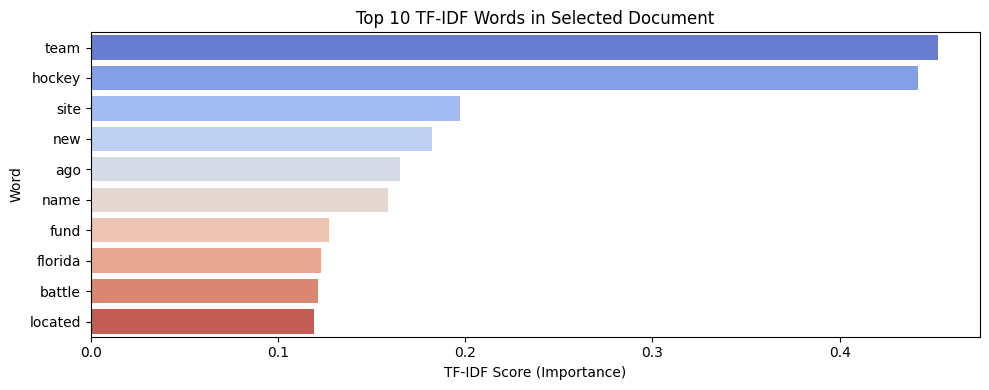


===== PIPELINE SUMMARY =====

STEP 1: Raw Text: Messy content, full of noise, punctuation, and unrelated metadata.
STEP 2: Cleaned Text: Lowercased, stopwords removed, punctuation removed, only relevant tokens kept.
STEP 3: TF-IDF Vector: Document converted into 3000-length vector of word importance scores.
STEP 4: Model Prediction: Logistic Regression uses the vector to classify into one of 20 topics.
STEP 5: Top TF-IDF Words: Helps us understand what the model focused on when deciding category.
STEP 6: Actual vs Predicted: Final check to confirm model behavior and correctness.

This end-to-end walkthrough shows the full transformation of a document
—from messy raw text to clean, interpretable prediction.
This builds trust, interpretability, and allows error analysis when model fails.



In [14]:
# ------------------------------------------------
# OBJECTIVE:
# Show how one document passes through the full ML pipeline:
#   1. Raw Text (before cleaning)
#   2. Cleaned Text (after preprocessing)
#   3. TF-IDF Vector Representation
#   4. Class Prediction using Trained Model
#   5. Top Words (TF-IDF features) influencing prediction
#   6. Actual vs Predicted Label Comparison
# ------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# STEP 11.1: SELECT A KNOWN CORRECTLY CLASSIFIED SAMPLE
# ------------------------------------------------

# Choose a test index that you already know is correct
test_row = 7  # Change this only if you verify another correct match
single_vector = X_test[test_row]
predicted_label_num = clf.predict(single_vector)[0]
true_label_num = y_test.iloc[test_row]

# ------------------------------------------------
# STEP 11.2: DISPLAY RAW VS CLEANED TEXT
# ------------------------------------------------
sample_index = y_test.index[test_row]
original_text = df_small.loc[sample_index, 'text']
cleaned_text = df_small.loc[sample_index, 'clean_text']

print("===== ORIGINAL TEXT (FIRST 500 CHARACTERS) =====")
print(original_text[:500])

print("\n===== CLEANED TEXT (AFTER PREPROCESSING) =====")
print(cleaned_text)

# ------------------------------------------------
# STEP 11.3: CLASSIFY THE DOCUMENT
# ------------------------------------------------

true_label_name = newsgroups.target_names[true_label_num]
predicted_label_name = newsgroups.target_names[predicted_label_num]

print("\n===== CLASSIFICATION RESULT =====")
print(f"Actual Category    : {true_label_name}")
print(f"Predicted Category : {predicted_label_name}")

if predicted_label_num == true_label_num:
    print("Model Prediction is CORRECT")
else:
    print("Model Prediction is WRONG")

# ------------------------------------------------
# STEP 11.4: SHOW TOP 10 TF-IDF WORDS IN THIS DOCUMENT
# ------------------------------------------------

doc_array = single_vector.toarray()[0]
top_indices = np.argsort(doc_array)[::-1][:10]
top_words = [tfidf.get_feature_names_out()[i] for i in top_indices]
top_scores = [doc_array[i] for i in top_indices]

print("\n===== TOP 10 TF-IDF WORDS IN THIS DOCUMENT =====")
for word, score in zip(top_words, top_scores):
    print(f"{word:20s} -> {score:.4f}")

# Bar chart for TF-IDF importance
plt.figure(figsize=(10, 4))
sns.barplot(x=top_scores, y=top_words, palette='coolwarm')
plt.title("Top 10 TF-IDF Words in Selected Document")
plt.xlabel("TF-IDF Score (Importance)")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# STEP 11.5: PIPELINE SUMMARY
# ------------------------------------------------
print("\n===== PIPELINE SUMMARY =====")
print("""
STEP 1: Raw Text: Messy content, full of noise, punctuation, and unrelated metadata.
STEP 2: Cleaned Text: Lowercased, stopwords removed, punctuation removed, only relevant tokens kept.
STEP 3: TF-IDF Vector: Document converted into 3000-length vector of word importance scores.
STEP 4: Model Prediction: Logistic Regression uses the vector to classify into one of 20 topics.
STEP 5: Top TF-IDF Words: Helps us understand what the model focused on when deciding category.
STEP 6: Actual vs Predicted: Final check to confirm model behavior and correctness.

This end-to-end walkthrough shows the full transformation of a document
—from messy raw text to clean, interpretable prediction.
This builds trust, interpretability, and allows error analysis when model fails.
""")
